In [2]:
# ==========================================================
# COVID DATA PREPARATION
# SECTION 1 : IMPORT LIBRARIES
# ==========================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("="*60)
print("COVID DATA PREPARATION STARTED")
print("="*60)

COVID DATA PREPARATION STARTED


In [3]:
# ==========================================================
# SECTION 2 : DATASET PATH
# ==========================================================

import os

COVID_DATASET_PATH = r"D:\Research_paper\Datasets\Covid_Data_set"

print("="*60)
print("COVID DATASET PATH")
print("="*60)

print(COVID_DATASET_PATH)

print("\nFolder Exists :", os.path.exists(COVID_DATASET_PATH))

print("\nAvailable Classes:")
print(os.listdir(COVID_DATASET_PATH))

COVID DATASET PATH
D:\Research_paper\Datasets\Covid_Data_set

Folder Exists : True

Available Classes:
['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [5]:
import os
print(os.listdir(COVID_DATASET_PATH))

['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [6]:
import os
print(f"Path current: {COVID_DATASET_PATH}")
print(f"Directory Contents: {os.listdir(COVID_DATASET_PATH)}")

Path current: D:\Research_paper\Datasets\Covid_Data_set
Directory Contents: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [4]:
# ==========================================================
# SECTION 3 : CLASS INFORMATION & IMAGE COUNT
# ==========================================================

import os

classes = sorted(os.listdir(COVID_DATASET_PATH))

print("="*60)
print("COVID DATASET INFORMATION")
print("="*60)

total_images = 0

for cls in classes:

    class_path = os.path.join(COVID_DATASET_PATH, cls)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    count = len(image_files)

    total_images += count

    print(f"{cls:<20} : {count} Images")

print("="*60)
print(f"TOTAL IMAGES : {total_images}")
print("="*60)

COVID DATASET INFORMATION
COVID                : 0 Images
Lung_Opacity         : 0 Images
Normal               : 0 Images
Viral Pneumonia      : 0 Images
TOTAL IMAGES : 0


In [10]:
import os

# Base path wahi rahega
COVID_DATASET_PATH = r"D:\Research_paper\Datasets\Covid_Data_set"

print("="*60)
print("COVID DATASET INFORMATION (Fixed)")
print("="*60)

total_images = 0
classes = sorted(os.listdir(COVID_DATASET_PATH))

for cls in classes:
    # Yahan humne '\images' add kar diya hai taaki file access sahi ho
    class_path = os.path.join(COVID_DATASET_PATH, cls, 'images')
    
    # Ye check karne ke liye ki folder exist karta hai ya nahi
    if os.path.exists(class_path):
        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        count = len(image_files)
        total_images += count
        print(f"{cls:<20} : {count} Images")
    else:
        print(f"{cls:<20} : Folder 'images' not found!")

print("="*60)
print(f"TOTAL IMAGES : {total_images}")
print("="*60)

COVID DATASET INFORMATION (Fixed)
COVID                : 3616 Images
Lung_Opacity         : 6012 Images
Normal               : 10192 Images
Viral Pneumonia      : 1345 Images
TOTAL IMAGES : 21165


{'COVID': 3616, 'Lung_Opacity': 6012, 'Normal': 10192, 'Viral Pneumonia': 1345}


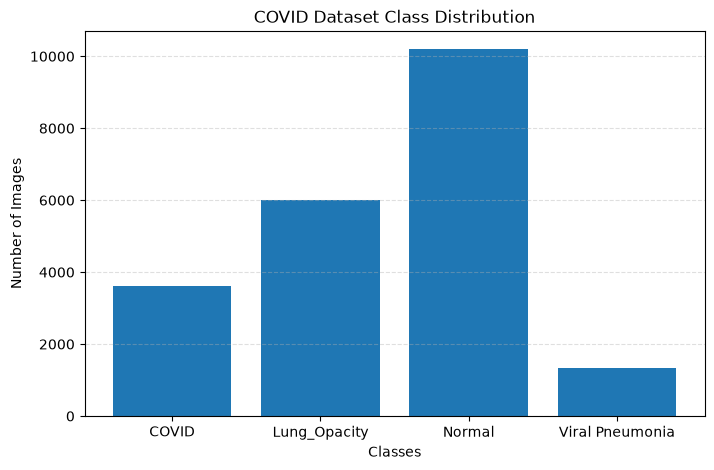

In [13]:
# ==========================================================
# SECTION 4 : CLASS DISTRIBUTION
# ==========================================================

import os
import matplotlib.pyplot as plt

class_counts = {}

for cls in classes:

    class_path = os.path.join(COVID_DATASET_PATH, cls)

    # Agar Images folder hai to uske andar jao
    if os.path.exists(os.path.join(class_path, "images")):
        class_path = os.path.join(class_path, "images")

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    class_counts[cls] = len(image_files)

print(class_counts)

plt.figure(figsize=(8,5))

plt.bar(class_counts.keys(), class_counts.values())

plt.title("COVID Dataset Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

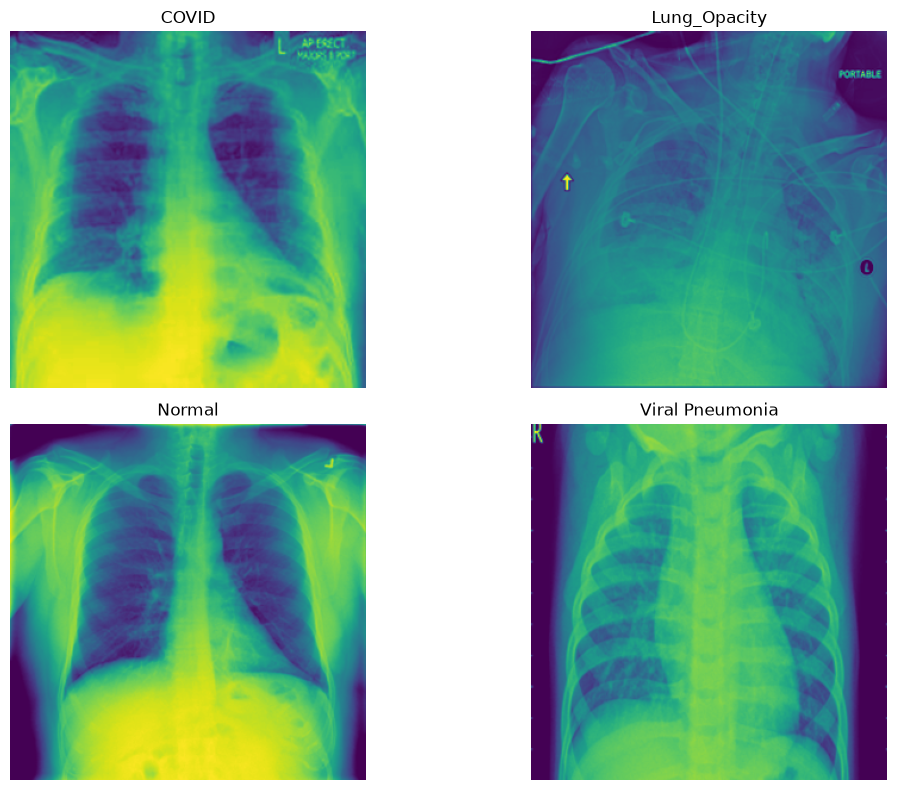

In [14]:
# ==========================================================
# SECTION 5 : RANDOM IMAGE VISUALIZATION
# ==========================================================

import random
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    image_folder = os.path.join(COVID_DATASET_PATH, cls, "images")

    image_list = [
        f for f in os.listdir(image_folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    random_image = random.choice(image_list)

    img_path = os.path.join(image_folder, random_image)

    img = Image.open(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [16]:
# ==========================================================
# SECTION 6 : TRAIN / VALIDATION / TEST SPLIT
# ==========================================================

import os
import shutil
from sklearn.model_selection import train_test_split

print("="*70)
print("COVID DATASET SPLITTING")
print("="*70)

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------

SOURCE_DIR = r"D:\Research_paper\Datasets\Covid_Data_set"

DEST_DIR = r"D:\Research_paper\Datasets\Covid_Data_set\Covid_Split"

# ----------------------------------------------------------
# Create Folder Structure
# ----------------------------------------------------------

for split in ["train", "validation", "test"]:
    os.makedirs(os.path.join(DEST_DIR, split), exist_ok=True)

classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

# ----------------------------------------------------------
# Split Dataset
# ----------------------------------------------------------

for cls in classes:

    print(f"\nProcessing Class : {cls}")

    source_images = os.path.join(SOURCE_DIR, cls, "images")

    images = [
        img for img in os.listdir(source_images)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    # ---------- 70% Train ----------

    train_imgs, temp_imgs = train_test_split(

        images,

        test_size=0.30,

        random_state=42,

        shuffle=True

    )

    # ---------- 15% Validation ----------
    # ---------- 15% Test ----------

    val_imgs, test_imgs = train_test_split(

        temp_imgs,

        test_size=0.50,

        random_state=42,

        shuffle=True

    )

    # ------------------------------------------------------
    # Create Class Folders
    # ------------------------------------------------------

    for split in ["train", "validation", "test"]:

        os.makedirs(

            os.path.join(DEST_DIR, split, cls),

            exist_ok=True

        )

    # ------------------------------------------------------
    # Copy Train Images
    # ------------------------------------------------------

    for img in train_imgs:

        shutil.copy2(

            os.path.join(source_images, img),

            os.path.join(DEST_DIR, "train", cls, img)

        )

    # ------------------------------------------------------
    # Copy Validation Images
    # ------------------------------------------------------

    for img in val_imgs:

        shutil.copy2(

            os.path.join(source_images, img),

            os.path.join(DEST_DIR, "validation", cls, img)

        )

    # ------------------------------------------------------
    # Copy Test Images
    # ------------------------------------------------------

    for img in test_imgs:

        shutil.copy2(

            os.path.join(source_images, img),

            os.path.join(DEST_DIR, "test", cls, img)

        )

    # ------------------------------------------------------
    # Print Statistics
    # ------------------------------------------------------

    print(f"Train      : {len(train_imgs)}")
    print(f"Validation : {len(val_imgs)}")
    print(f"Test       : {len(test_imgs)}")

print("\n" + "="*70)
print("✅ DATASET SPLITTING COMPLETED")
print("="*70)

print("\nDataset Saved At:")

print(DEST_DIR)

COVID DATASET SPLITTING

Processing Class : COVID
Train      : 2531
Validation : 542
Test       : 543

Processing Class : Lung_Opacity
Train      : 4208
Validation : 902
Test       : 902

Processing Class : Normal
Train      : 7134
Validation : 1529
Test       : 1529

Processing Class : Viral Pneumonia
Train      : 941
Validation : 202
Test       : 202

✅ DATASET SPLITTING COMPLETED

Dataset Saved At:
D:\Research_paper\Datasets\Covid_Data_set\Covid_Split
